# Fed Inflation CPI

This notebook pulls the official CPI and core CPI series from FRED, calculates year-over-year inflation rates, and plots both the index levels and inflation rates.

Source series: `CPIAUCSL` and `CPILFESL` from the Federal Reserve Bank of St. Louis FRED database.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
headline_url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL'
core_url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPILFESL'

headline = pd.read_csv(headline_url)
core = pd.read_csv(core_url)

headline['observation_date'] = pd.to_datetime(headline['observation_date'])
core['observation_date'] = pd.to_datetime(core['observation_date'])

headline = headline.rename(columns={'observation_date': 'date', 'CPIAUCSL': 'headline_cpi'})
core = core.rename(columns={'observation_date': 'date', 'CPILFESL': 'core_cpi'})

inflation = headline.merge(core, on='date', how='inner').dropna().sort_values('date').reset_index(drop=True)
inflation['headline_yoy_pct'] = inflation['headline_cpi'].pct_change(12) * 100
inflation['core_yoy_pct'] = inflation['core_cpi'].pct_change(12) * 100

latest = inflation.iloc[-1]

print(f"Latest date: {latest['date'].date()}")
print(f"CPI (All Items) level: {latest['headline_cpi']:.3f}")
print(f"Core CPI (Excluding Food and Energy) level: {latest['core_cpi']:.3f}")
print(f"CPI (All Items) YoY inflation: {latest['headline_yoy_pct']:.2f}%")
print(f"Core CPI (Excluding Food and Energy) YoY inflation: {latest['core_yoy_pct']:.2f}%")

inflation.tail()


Latest date: 2026-05-01
CPI (All Items) level: 333.979
Core CPI (Excluding Food and Energy) level: 336.121
CPI (All Items) YoY inflation: 4.27%
Core CPI (Excluding Food and Energy) YoY inflation: 2.96%


date,headline_cpi,core_cpi,headline_yoy_pct,core_yoy_pct
2026-01-01,326.588,332.793,2.828680,2.949338
2026-02-01,327.460,333.512,2.664589,2.733506
2026-03-01,330.293,334.165,3.320206,2.673098
2026-04-01,332.407,335.423,3.947027,2.988425
2026-05-01,333.979,336.121,4.270033,2.957114


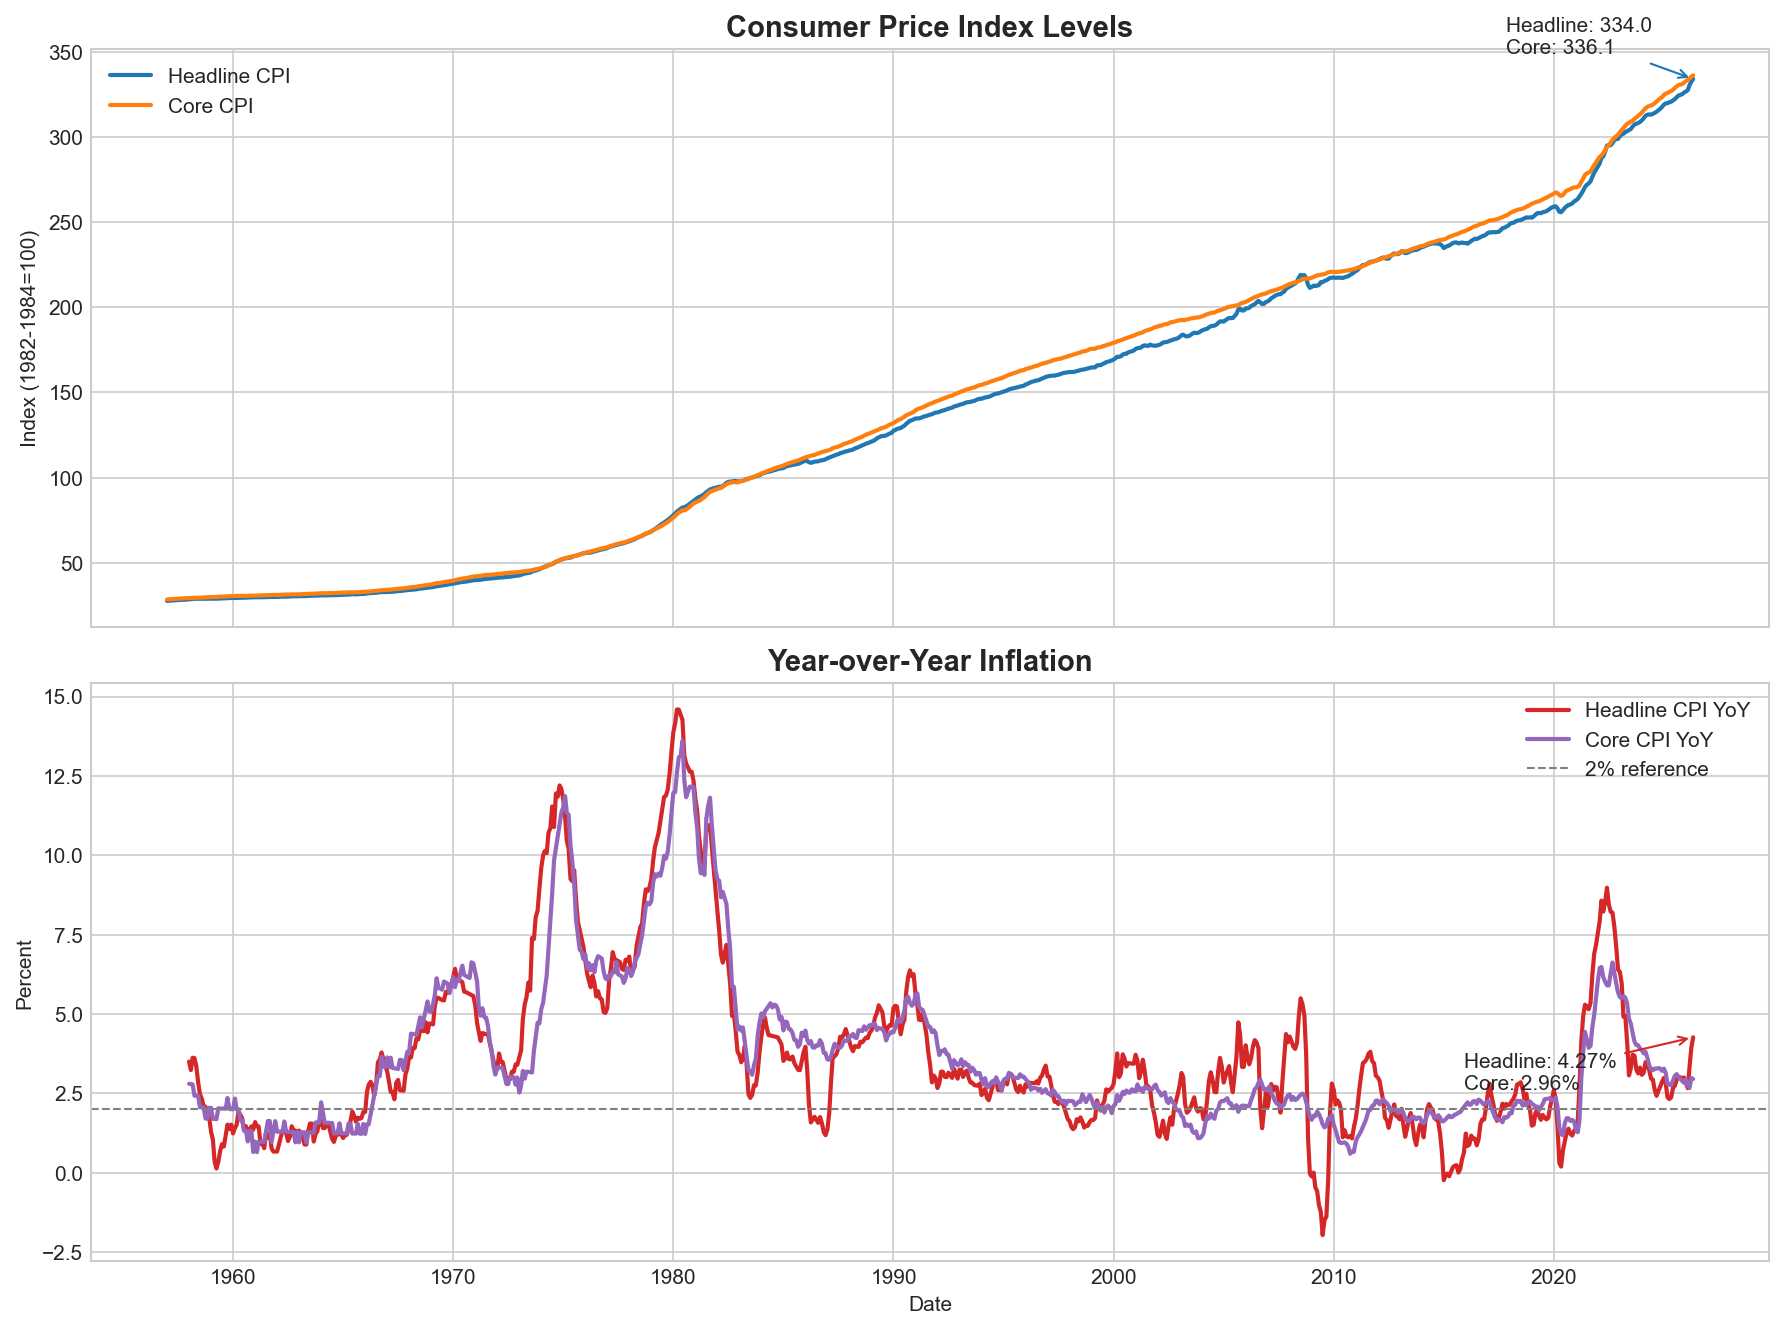

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(inflation['date'], inflation['headline_cpi'], color='#1f77b4', linewidth=2, label='CPI (All Items)')
axes[0].plot(inflation['date'], inflation['core_cpi'], color='#ff7f0e', linewidth=2, label='Core CPI (Excluding Food and Energy)')
axes[0].set_title('Consumer Price Index Levels', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Index (1982-1984=100)')
axes[0].annotate(
    f"CPI (All Items): {latest['headline_cpi']:.1f}\nCore CPI ex Food & Energy: {latest['core_cpi']:.1f}",
    xy=(latest['date'], latest['headline_cpi']),
    xytext=(-90, 12),
    textcoords='offset points',
    arrowprops={'arrowstyle': '->', 'color': '#1f77b4'}
)
axes[0].legend(frameon=False)

yoy = inflation.dropna(subset=['headline_yoy_pct', 'core_yoy_pct'])
axes[1].plot(yoy['date'], yoy['headline_yoy_pct'], color='#d62728', linewidth=2, label='CPI (All Items) YoY')
axes[1].plot(yoy['date'], yoy['core_yoy_pct'], color='#9467bd', linewidth=2, label='Core CPI ex Food & Energy YoY')
axes[1].axhline(2.0, color='gray', linestyle='--', linewidth=1, label='2% reference')
axes[1].set_title('Year-over-Year Inflation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percent')
axes[1].set_xlabel('Date')
axes[1].legend(frameon=False)
axes[1].annotate(
    f"CPI (All Items): {latest['headline_yoy_pct']:.2f}%\nCore CPI ex Food & Energy: {latest['core_yoy_pct']:.2f}%",
    xy=(latest['date'], latest['headline_yoy_pct']),
    xytext=(-110, -25),
    textcoords='offset points',
    arrowprops={'arrowstyle': '->', 'color': '#d62728'}
)

plt.tight_layout()
plt.show()


## Notes

- FRED series: [CPIAUCSL](https://fred.stlouisfed.org/series/CPIAUCSL) and [CPILFESL](https://fred.stlouisfed.org/series/CPILFESL)
- Source agency: U.S. Bureau of Labor Statistics, via the Federal Reserve Bank of St. Louis
- The notebook computes year-over-year inflation as the percent change versus the same month one year earlier
- Core CPI excludes food and energy
